# Análise Exploratória do Golden Set

Exploração da amostra estratificada `golden_clients.csv` (2 595 clientes únicos) extraída do dataset sintético BR.
O objetivo é entender a composição da base antes de treinar e avaliar os braços MAB.

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110})

In [2]:
df = pd.read_csv("../data/golden_set/golden_clients.csv", low_memory=False)

PRODUCT_COLS = [c for c in df.columns if c.startswith("possui_")]
NUM_COLS     = ["idade", "renda_estimada_anual_brl", "tempo_relacionamento_meses"]
CAT_COLS     = ["sexo", "segmento", "estado", "canal_entrada"]
ARM_PRODUCTS = [
    "possui_emprestimo_pessoal", "possui_cartao_credito", "possui_financiamento_imovel",
    "possui_fundo_investimento", "possui_cdb_curto_prazo",
    "possui_previdencia_privada", "possui_titulos_investimento",
]

df["n_produtos"] = df[PRODUCT_COLS].sum(axis=1)

print(f"Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
df.head(3)

Shape: 2,595 linhas x 49 colunas


,cod_cliente,data_referencia,ind_funcionario,pais_residencia,sexo,idade,data_cadastro,ind_novo,tempo_relacionamento_meses,ind_relacionamento,ult_data_cliente_principal,ind_rel_inicio_mes,tipo_rel_inicio_mes,ind_residente,ind_estrangeiro,conjuge_funcionario,canal_entrada,ind_falecido,estado,ind_ativo,renda_estimada_anual_brl,segmento,possui_poupanca,possui_aval_garantia,possui_conta_corrente,possui_conta_investimento,possui_conta_salario,possui_conta_junior,possui_conta_universitaria,possui_conta_corrente_plus,possui_conta_premium,possui_cdb_curto_prazo,possui_cdb_medio_prazo,possui_cdb_longo_prazo,possui_conta_digital,possui_fundo_investimento,possui_financiamento_imovel,possui_previdencia_privada,possui_emprestimo_pessoal,possui_pagamento_tributos,possui_cartao_credito,possui_titulos_investimento,possui_financiamento_veiculo,possui_folha_pagamento,possui_beneficio_previdencia,possui_debito_automatico,segmentos_sinteticos,evento_viagem_sintetico,n_produtos
0,100870,2022-10-28,N,BR,M,45,2005-06-30,0.00,208,1.00,NaN,1.00,A,S,N,NaN,KAT,N,SP,1.00,"47,821.31",02 - VAREJO,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,1,1.00,1.00,1,"[""SEG-CREDITO-ATIVO"", ""SEG-INVESTIDOR-INICIANT...",0,9.00
1,1186912,2023-01-28,N,BR,M,23,2020-10-01,0.00,27,1.00,NaN,1.00,A,S,N,NaN,KHE,N,SP,1.00,"146,222.00",03 - UNIVERSITARIO,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,0.00,0,"[""SEG-JOVEM"", ""SEG-CREDITO-ATIVO"", ""SEG-SEM-CA...",0,1.00
2,952537,2023-04-28,N,BR,F,26,2018-10-01,0.00,54,1.00,NaN,1.00,A,S,S,NaN,KAT,N,PA,1.00,"189,376.26",03 - UNIVERSITARIO,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0.00,0.00,1,"[""SEG-JOVEM"", ""SEG-ALTA-RENDA"", ""SEG-CREDITO-A...",0,3.00


## Visão Geral do Dataset

### Qual é a composição e dimensão dos dados?

In [3]:
tipo_counts = df.dtypes.value_counts().rename_axis("dtype").reset_index(name="colunas")
tipo_counts["dtype"] = tipo_counts["dtype"].astype(str)
display(tipo_counts)

print("\nEstatísticas descritivas — variáveis numéricas:")
display(df[NUM_COLS + ["n_produtos"]].describe().T.round(2))

,dtype,colunas
0,int64,26
1,str,15
2,float64,8



Estatísticas descritivas — variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
idade,"2,595.00",45.92,16.51,18.00,33.00,46.00,55.00,100.00
renda_estimada_anual_brl,"2,595.00","93,590.34","108,186.53","7,130.65","29,548.31","56,631.12","108,324.90","696,420.24"
tempo_relacionamento_meses,"2,595.00",103.25,70.62,0.00,35.00,103.00,166.00,252.00
n_produtos,"2,595.00",2.45,2.24,0.00,1.00,2.00,3.00,12.00


### Onde estão os dados faltantes - há variáveis inutilizáveis?

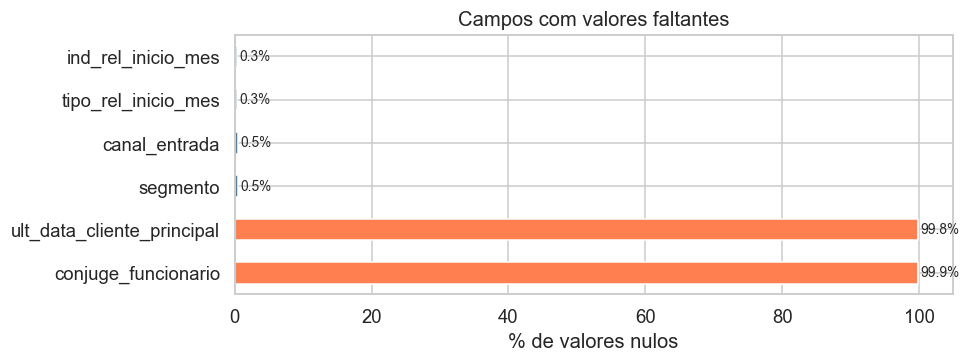

Nota: 'conjuge_funcionario' e 'ult_data_cliente_principal' (>99% nulos) devem ser descartadas do modelo.


In [4]:
nulos = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
nulos = nulos[nulos > 0]

fig, ax = plt.subplots(figsize=(9, 3.5))
colors = ["coral" if v > 50 else "steelblue" for v in nulos.values]
nulos.plot.barh(ax=ax, color=colors)
ax.set_xlabel("% de valores nulos")
ax.set_title("Campos com valores faltantes")
for bar in ax.patches:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Nota: 'conjuge_funcionario' e 'ult_data_cliente_principal' (>99% nulos) devem ser descartadas do modelo.")

## Variáveis Numéricas

### Como se distribuem idade, renda e tempo de relacionamento?

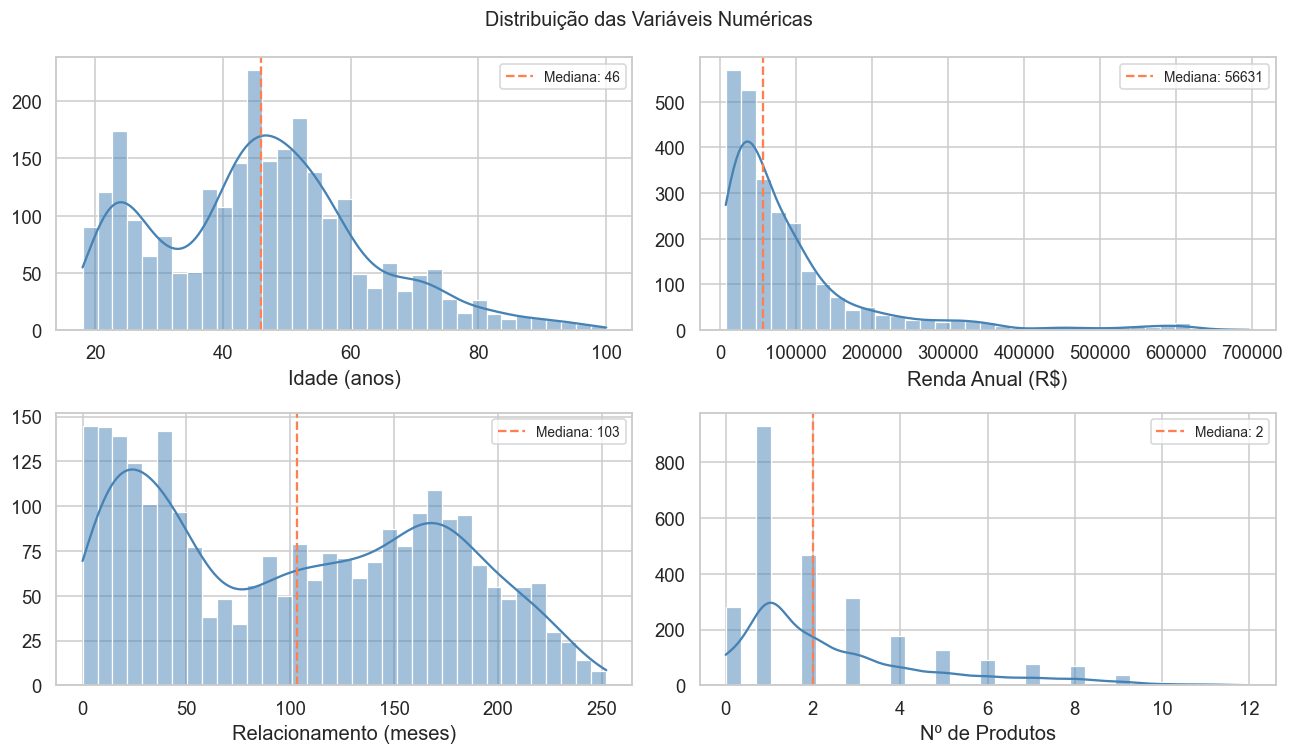

In [5]:
cols_labels = [
    ("idade",                      "Idade (anos)"),
    ("renda_estimada_anual_brl",   "Renda Anual (R$)"),
    ("tempo_relacionamento_meses", "Relacionamento (meses)"),
    ("n_produtos",                 "Nº de Produtos"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (col, label) in zip(axes.flat, cols_labels):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue", bins=35)
    med = df[col].median()
    ax.axvline(med, color="coral", linestyle="--", linewidth=1.5,
               label=f"Mediana: {med:.0f}")
    ax.set_xlabel(label)
    ax.set_ylabel("")
    ax.legend(fontsize=9)

plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=13)
plt.tight_layout()
plt.show()

### A renda tem outliers severos que concentram riqueza em poucos clientes?

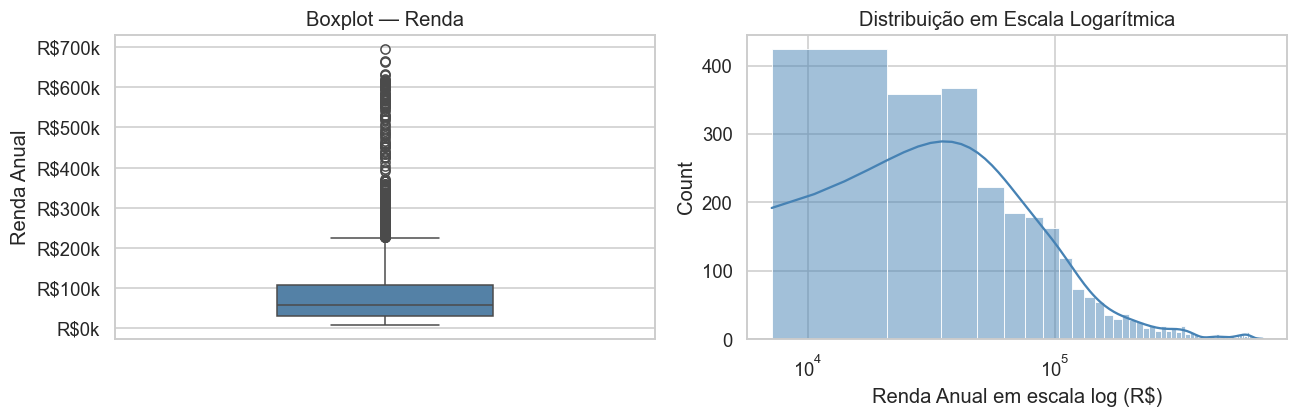

,P10,P25,P50,P75,P90,P95,P99
Renda Anual (R$),"14,303.37","29,548.31","56,631.12","108,324.90","212,839.43","315,492.51","582,648.69"



Outliers (>Q3+1.5xIQR = R$226,490): 238 clientes (9.2%)
Skewness: 2.67 | Kurtosis: 8.20


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df["renda_estimada_anual_brl"], ax=axes[0], color="steelblue", width=0.4)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1_000:.0f}k")
)
axes[0].set_ylabel("Renda Anual")
axes[0].set_title("Boxplot — Renda")

sns.histplot(df["renda_estimada_anual_brl"], kde=True, ax=axes[1],
             color="steelblue", bins=50)
axes[1].set_xscale("log")
axes[1].set_xlabel("Renda Anual em escala log (R$)")
axes[1].set_title("Distribuição em Escala Logarítmica")

plt.tight_layout()
plt.show()

pcts = df["renda_estimada_anual_brl"].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
pcts.index = ["P10", "P25", "P50", "P75", "P90", "P95", "P99"]
display(pcts.rename("Renda Anual (R$)").to_frame().T)

q1, q3 = df["renda_estimada_anual_brl"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
outliers_n = (df["renda_estimada_anual_brl"] > upper).sum()
print(f"\nOutliers (>Q3+1.5xIQR = R${upper:,.0f}): {outliers_n} clientes ({outliers_n/len(df)*100:.1f}%)")
print(f"Skewness: {df['renda_estimada_anual_brl'].skew():.2f} | Kurtosis: {df['renda_estimada_anual_brl'].kurt():.2f}")

## Variáveis Categóricas

### A base é diversa em sexo, segmento e distribuição geográfica?

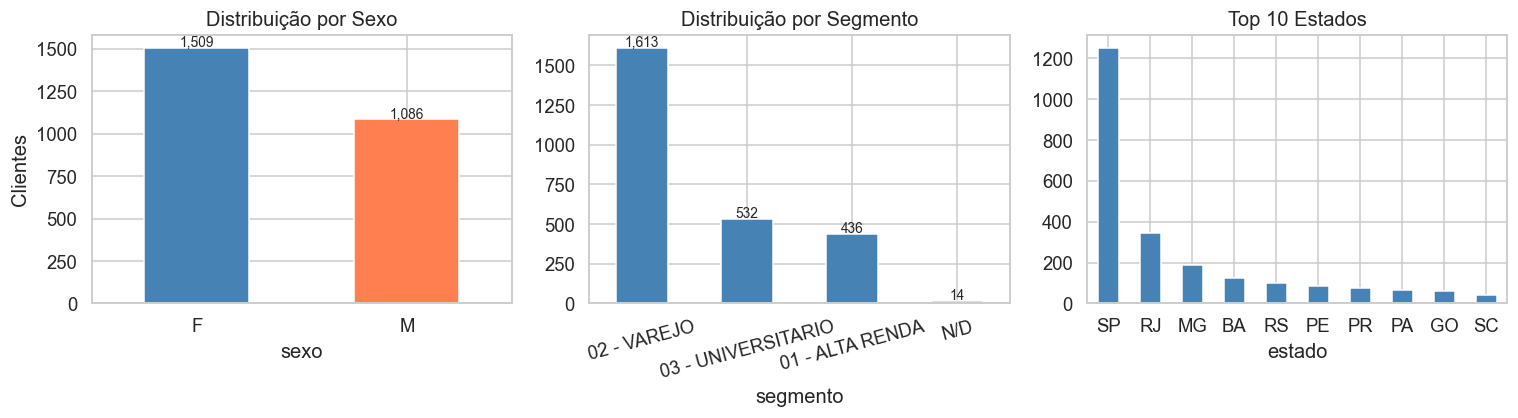

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Sexo
vc_sexo = df["sexo"].value_counts()
vc_sexo.plot.bar(ax=axes[0], color=["steelblue", "coral"], rot=0)
axes[0].set_title("Distribuição por Sexo")
axes[0].set_ylabel("Clientes")
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                 f"{bar.get_height():,.0f}", ha="center", fontsize=9)

# Segmento
vc_seg = df["segmento"].fillna("N/D").value_counts()
vc_seg.plot.bar(ax=axes[1], color="steelblue", rot=15)
axes[1].set_title("Distribuição por Segmento")
axes[1].set_ylabel("")
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                 f"{bar.get_height():,.0f}", ha="center", fontsize=9)

# Estado top 10
df["estado"].value_counts().head(10).plot.bar(ax=axes[2], color="steelblue", rot=0)
axes[2].set_title("Top 10 Estados")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

### Qual canal de entrada concentra a maior parte dos clientes?

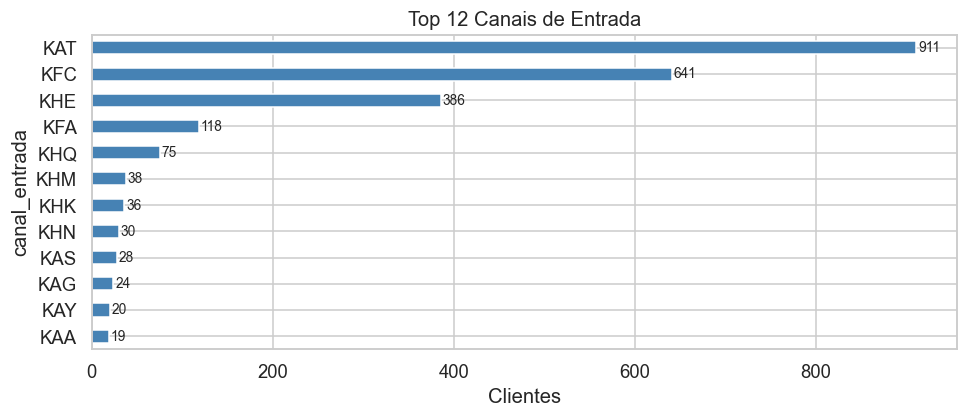

In [8]:
top_canal = df["canal_entrada"].value_counts().head(12).sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
top_canal.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Clientes")
ax.set_title("Top 12 Canais de Entrada")
for bar in ax.patches:
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## Portfólio de Produtos Financeiros

### Os produtos bancários básicos dominam - o que sobra para os braços MAB explorarem?

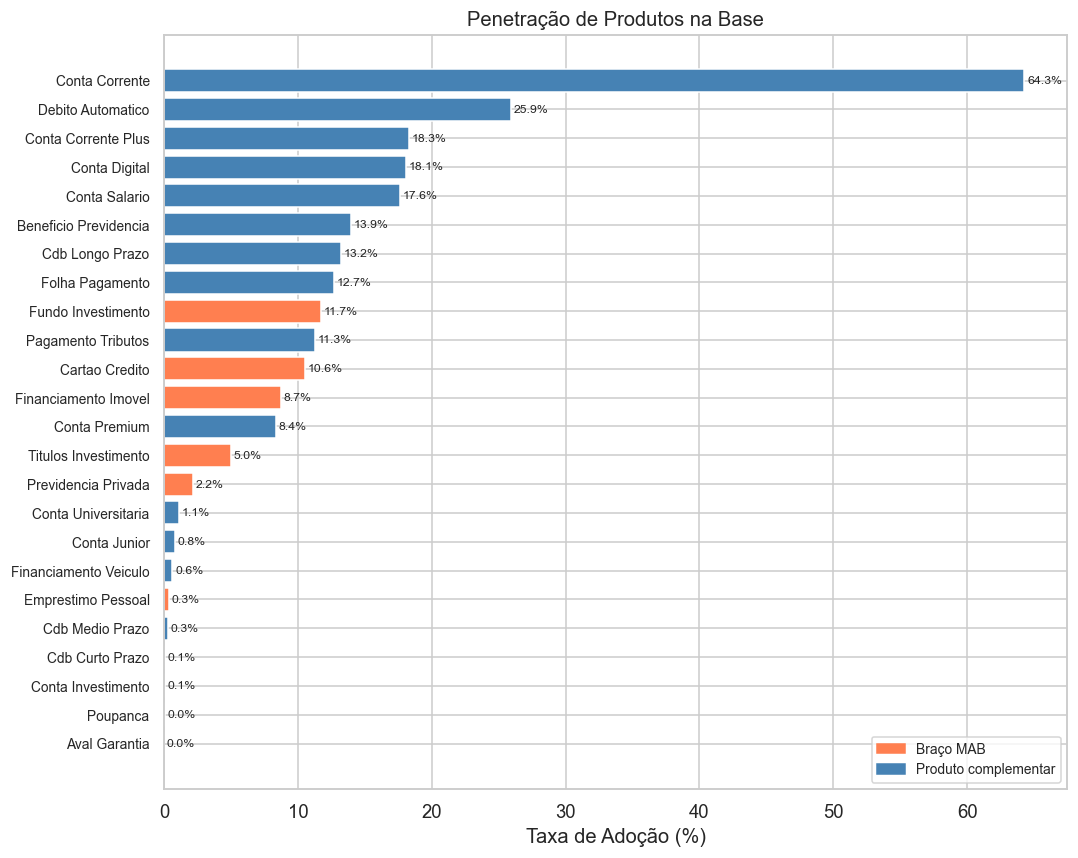

In [9]:
adoption = df[PRODUCT_COLS].mean().sort_values(ascending=True)
labels = {c: c.replace("possui_", "").replace("_", " ").title() for c in adoption.index}
is_arm = adoption.index.isin(ARM_PRODUCTS)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["coral" if arm else "steelblue" for arm in is_arm]
ax.barh(range(len(adoption)), adoption.values * 100, color=colors)
ax.set_yticks(range(len(adoption)))
ax.set_yticklabels([labels[c] for c in adoption.index], fontsize=9)
ax.set_xlabel("Taxa de Adoção (%)")
ax.set_title("Penetração de Produtos na Base")
for i, v in enumerate(adoption.values):
    ax.text(v * 100 + 0.2, i, f"{v * 100:.1f}%", va="center", fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="coral",     label="Braço MAB"),
    Patch(color="steelblue", label="Produto complementar"),
], loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

### Clientes de alta renda têm portfólio mais diversificado do que os de varejo?

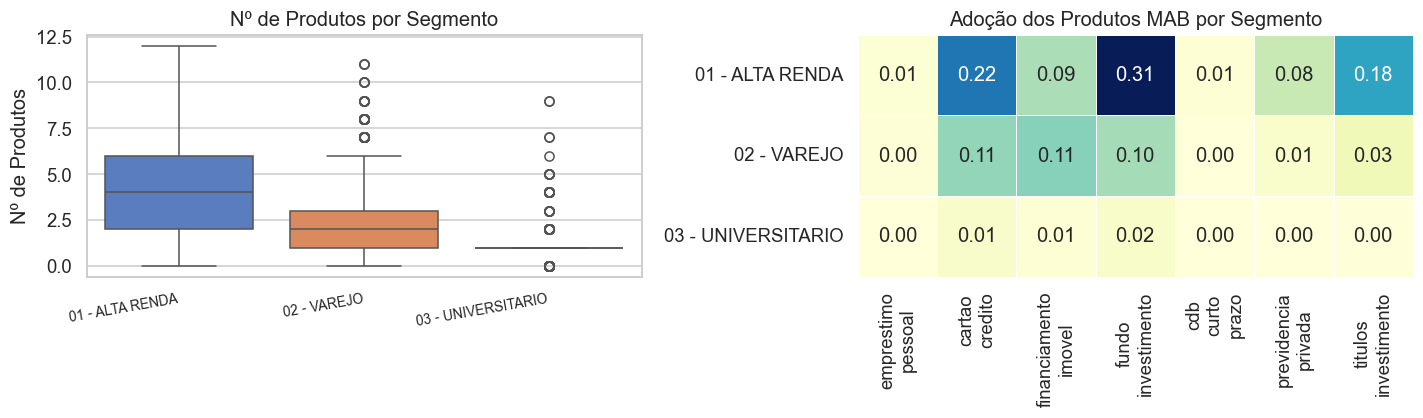

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot nº de produtos por segmento
order = df.groupby("segmento")["n_produtos"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="segmento", y="n_produtos",
            order=order, palette="muted", ax=axes[0])
axes[0].set_title("Nº de Produtos por Segmento")
axes[0].set_xlabel("")
axes[0].set_ylabel("Nº de Produtos")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=10, ha="right", fontsize=9)

# Heatmap adoção dos braços MAB por segmento
heat = df.groupby("segmento")[ARM_PRODUCTS].mean().round(3)
heat.columns = [c.replace("possui_", "").replace("_", "\n") for c in heat.columns]
sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlGnBu",
            ax=axes[1], cbar=False, linewidths=0.5)
axes[1].set_title("Adoção dos Produtos MAB por Segmento")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

## Segmentos Sintéticos do MAB

### Os segmentos de elegibilidade têm cobertura suficiente para avaliar todos os braços?

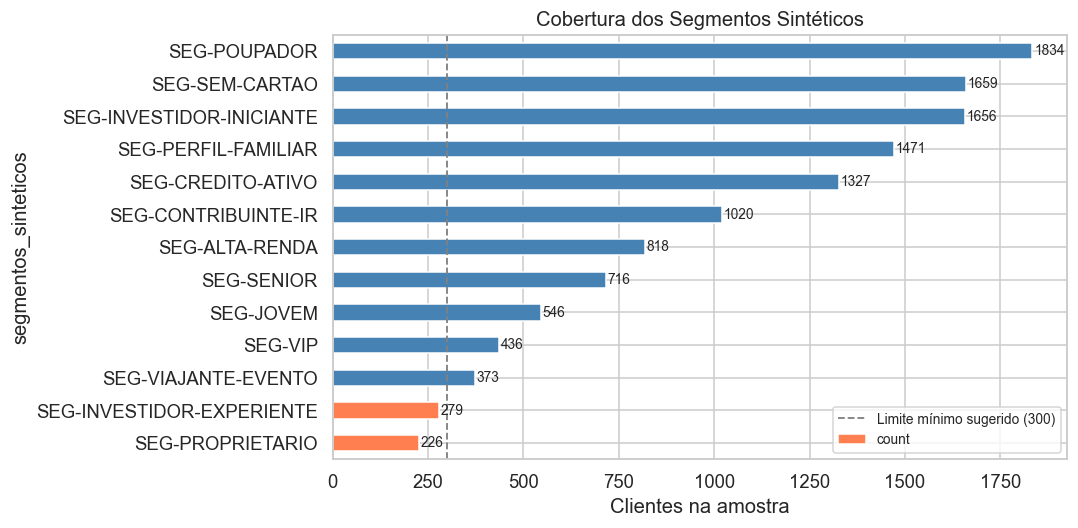

,clientes,% da amostra
segmentos_sinteticos,,
SEG-PROPRIETARIO,226,8.70
SEG-INVESTIDOR-EXPERIENTE,279,10.80
SEG-VIAJANTE-EVENTO,373,14.40
SEG-VIP,436,16.80
SEG-JOVEM,546,21.00
SEG-SENIOR,716,27.60
SEG-ALTA-RENDA,818,31.50
SEG-CONTRIBUINTE-IR,1020,39.30
SEG-CREDITO-ATIVO,1327,51.10


In [11]:
seg_counts = (
    df["segmentos_sinteticos"]
    .apply(lambda x: json.loads(x) if pd.notna(x) else [])
    .explode()
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["coral" if v < 300 else "steelblue" for v in seg_counts.values]
seg_counts.plot.barh(ax=ax, color=colors)
ax.set_xlabel("Clientes na amostra")
ax.set_title("Cobertura dos Segmentos Sintéticos")
ax.axvline(300, color="gray", linestyle="--", linewidth=1.2, label="Limite mínimo sugerido (300)")
ax.legend(fontsize=9)
for bar in ax.patches:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width())}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

pct = (seg_counts / len(df) * 100).round(1).rename("% da amostra")
display(pd.concat([seg_counts.rename("clientes"), pct], axis=1).sort_values("clientes"))

## Dispersão e Assimetria nas Variáveis de Contexto

### As variáveis de contexto do MAB têm distribuição adequada para modelos lineares?

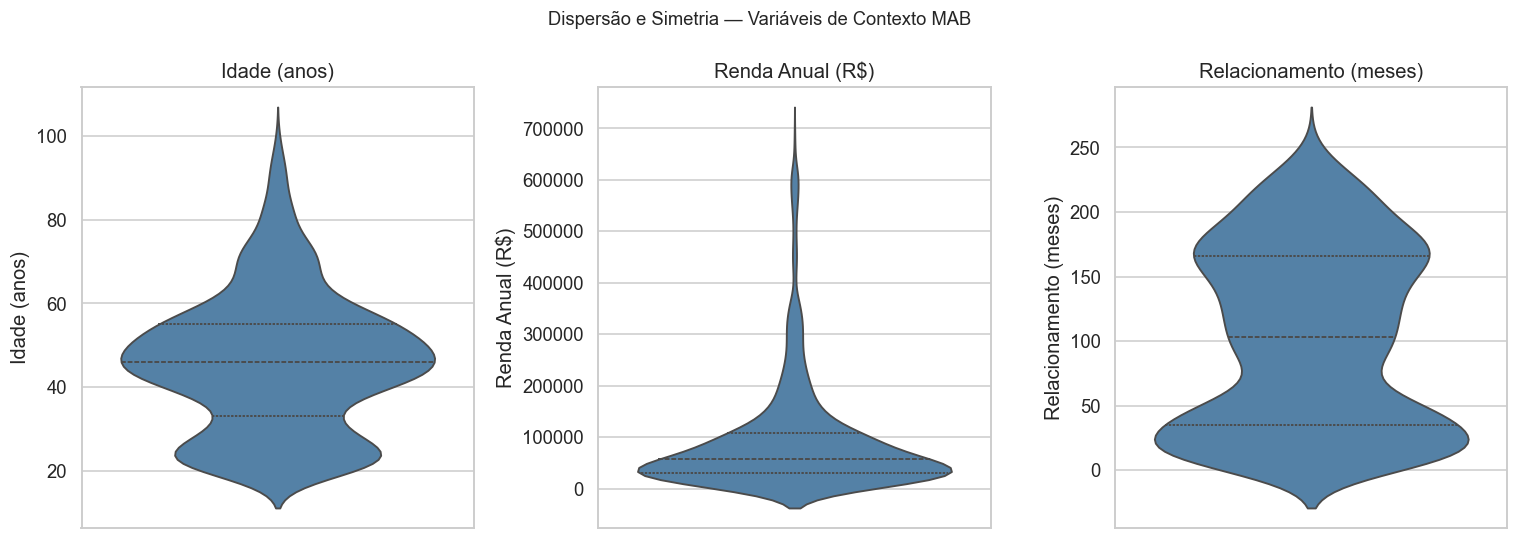

,Média,Mediana,Desvio Padrão,Skewness,Kurtosis
Variável,,,,,
Idade (anos),45.9,46.0,16.5,0.40,-0.05
Renda Anual (R$),"93,590.3","56,631.1","108,186.5",2.67,8.20
Relacionamento (meses),103.3,103.0,70.6,0.14,-1.32



Nota: renda_estimada_anual_brl tem skewness > 2 — normalizar (log ou quantil) antes de usar em LinUCB.


In [12]:
label_map = {
    "idade":                      "Idade (anos)",
    "renda_estimada_anual_brl":   "Renda Anual (R$)",
    "tempo_relacionamento_meses": "Relacionamento (meses)",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, NUM_COLS):
    sns.violinplot(y=df[col].dropna(), ax=ax, color="steelblue", inner="quartile")
    ax.set_ylabel(label_map[col])
    ax.set_xlabel("")
    ax.set_title(label_map[col])

plt.suptitle("Dispersão e Simetria — Variáveis de Contexto MAB", fontsize=12)
plt.tight_layout()
plt.show()

stats = pd.DataFrame({
    "Variável":      label_map.values(),
    "Média":         [df[c].mean()  for c in NUM_COLS],
    "Mediana":       [df[c].median() for c in NUM_COLS],
    "Desvio Padrão": [df[c].std()   for c in NUM_COLS],
    "Skewness":      [df[c].skew()  for c in NUM_COLS],
    "Kurtosis":      [df[c].kurt()  for c in NUM_COLS],
}).set_index("Variável")

display(
    stats.style
    .format({"Média": "{:,.1f}", "Mediana": "{:,.1f}",
             "Desvio Padrão": "{:,.1f}", "Skewness": "{:.2f}", "Kurtosis": "{:.2f}"})
    .background_gradient(subset=["Skewness"], cmap="RdYlGn_r")
)

print("\nNota: renda_estimada_anual_brl tem skewness > 2 — normalizar (log ou quantil) antes de usar em LinUCB.")